In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
#build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
#build the dataset

block_size = 3 #context length
X, Y = [],[]

for w in words[:5]:

    print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context),'---->',itos[ix])
        context = context[1:] + [ix] #crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [8]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [9]:
C = torch.randn((27,2))
C

tensor([[ 1.0402,  2.4135],
        [-1.7144,  0.7232],
        [ 1.3888, -2.0149],
        [ 0.1689,  0.2530],
        [-0.1646,  0.6984],
        [-1.5851, -0.4214],
        [ 1.1442, -0.4030],
        [-0.2108,  0.6719],
        [ 1.4050,  0.7770],
        [ 0.0613, -0.7757],
        [ 0.8412, -0.6303],
        [-0.6049, -1.0455],
        [ 0.6886, -0.8759],
        [-0.0292,  0.5136],
        [-1.0697,  0.4525],
        [ 0.2179, -0.5565],
        [-0.7164,  0.2529],
        [ 0.3816, -0.1365],
        [-0.9096,  0.6145],
        [ 0.3215, -0.0619],
        [ 0.1047,  0.5795],
        [-1.6031, -1.3221],
        [-0.3853,  0.0654],
        [ 0.5463, -0.8254],
        [ 2.2199,  0.6594],
        [ 0.8954, -1.8004],
        [ 1.2835,  1.2202]])

In [10]:
C[5]

tensor([-1.5851, -0.4214])

In [11]:
F.one_hot(torch.tensor(5),num_classes=27).float() @ C

tensor([-1.5851, -0.4214])

In [14]:
#imagine each data in X stacked in vertical axis then the 3 characters of each xi point toward the x axis and their 2 number embedding points toward the y-axis
C[X].shape

torch.Size([32, 3, 2])

In [16]:
#it will return the embedding of the second element of x13 which is 1
C[X][13,2]

tensor([-1.7144,  0.7232])

In [17]:
emb = C[X]

In [18]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [19]:
#transformring 32*3*2 into 32*6 for matrix multiplication
# method - 1 ) torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]],1).shape
# method - 2 ) torch.cat(torch.unbind(emb,1),1).shape
# method - 3 ) emb.view(32,6) -> best method 

In [21]:
emb.view(32,6)

tensor([[ 1.0402,  2.4135,  1.0402,  2.4135,  1.0402,  2.4135],
        [ 1.0402,  2.4135,  1.0402,  2.4135, -1.5851, -0.4214],
        [ 1.0402,  2.4135, -1.5851, -0.4214, -0.0292,  0.5136],
        [-1.5851, -0.4214, -0.0292,  0.5136, -0.0292,  0.5136],
        [-0.0292,  0.5136, -0.0292,  0.5136, -1.7144,  0.7232],
        [ 1.0402,  2.4135,  1.0402,  2.4135,  1.0402,  2.4135],
        [ 1.0402,  2.4135,  1.0402,  2.4135,  0.2179, -0.5565],
        [ 1.0402,  2.4135,  0.2179, -0.5565,  0.6886, -0.8759],
        [ 0.2179, -0.5565,  0.6886, -0.8759,  0.0613, -0.7757],
        [ 0.6886, -0.8759,  0.0613, -0.7757, -0.3853,  0.0654],
        [ 0.0613, -0.7757, -0.3853,  0.0654,  0.0613, -0.7757],
        [-0.3853,  0.0654,  0.0613, -0.7757, -1.7144,  0.7232],
        [ 1.0402,  2.4135,  1.0402,  2.4135,  1.0402,  2.4135],
        [ 1.0402,  2.4135,  1.0402,  2.4135, -1.7144,  0.7232],
        [ 1.0402,  2.4135, -1.7144,  0.7232, -0.3853,  0.0654],
        [-1.7144,  0.7232, -0.3853,  0.0

In [26]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
print(h.shape)
h

torch.Size([32, 100])


tensor([[-0.9999,  0.8975,  0.5770,  ..., -0.8771,  0.7166,  1.0000],
        [-0.9971, -0.9506,  0.5097,  ..., -0.4059,  0.9558,  1.0000],
        [ 0.9996, -0.4744, -0.3486,  ...,  0.8876,  0.9810,  1.0000],
        ...,
        [-0.9986,  0.8623, -0.6817,  ...,  0.9482, -0.2673, -0.8242],
        [-0.9999, -0.2011,  0.4766,  ..., -0.5933, -0.3385,  0.2499],
        [ 0.9997, -0.9996,  0.9303,  ..., -0.5009,  0.8536,  0.9836]])

In [27]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [28]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [30]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims = True)
print(prob.shape)
prob

torch.Size([32, 27])


tensor([[7.5660e-13, 1.0646e-14, 5.3794e-09, 2.4356e-09, 6.4117e-13, 1.6845e-14,
         6.2177e-07, 4.2736e-14, 1.1193e-12, 2.2036e-10, 3.3504e-13, 1.3564e-14,
         5.4944e-13, 8.8246e-12, 9.4293e-11, 3.5810e-12, 7.3858e-08, 1.2156e-04,
         9.9910e-01, 8.2876e-06, 6.8028e-05, 7.0282e-04, 1.2434e-12, 9.1043e-12,
         1.2023e-11, 1.2518e-08, 9.0293e-15],
        [5.1192e-12, 2.5274e-09, 4.8547e-08, 3.3935e-02, 4.1685e-07, 4.8579e-10,
         3.3780e-08, 6.6887e-10, 1.6360e-13, 2.1862e-08, 3.1744e-09, 4.7055e-03,
         2.2091e-12, 2.0733e-11, 5.4987e-06, 1.8336e-06, 9.5928e-07, 1.2828e-02,
         3.8329e-06, 1.0490e-05, 9.4848e-01, 7.7529e-09, 4.4591e-13, 1.0076e-10,
         3.5422e-11, 1.7524e-09, 2.5147e-05],
        [4.3156e-13, 1.7683e-10, 6.6436e-05, 2.1637e-04, 9.5259e-11, 8.3901e-06,
         3.8429e-03, 2.4726e-09, 3.4916e-18, 9.9327e-05, 6.5096e-09, 6.8055e-06,
         2.3018e-12, 1.2564e-11, 2.0391e-03, 5.2922e-01, 6.3926e-10, 4.5757e-08,
         8.9482e-

In [32]:
prob[1].sum()

tensor(1.)

In [33]:
# the probability of the output Y for each of the 32 contexts as predicted by the model initially
prob[torch.arange(32),Y]

tensor([1.6845e-14, 2.0733e-11, 1.2564e-11, 7.3080e-03, 2.3685e-04, 3.5810e-12,
        6.4693e-13, 7.8830e-01, 1.4805e-03, 1.7075e-08, 2.2001e-04, 2.3668e-08,
        1.0646e-14, 1.8404e-11, 2.4931e-08, 5.6777e-06, 2.2036e-10, 8.3286e-04,
        1.2663e-12, 9.9973e-01, 1.9475e-07, 4.2433e-12, 8.2685e-01, 5.0862e-08,
        3.5448e-06, 8.2876e-06, 1.4098e-11, 1.8017e-08, 1.3322e-15, 5.3308e-06,
        1.8519e-10, 1.6247e-15])

In [34]:
# loss = -torch.log(prob[torch.arange(32),Y]).mean()
loss = -prob[torch.arange(32),Y].log().mean()
loss

tensor(17.8584)

In [69]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C, W1, b1, W2, b2]

In [70]:
sum(p.nelement() for p in parameters)
#number of parameters in total

3481

In [71]:
emb = C[X] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @ W2 + b2 # (32,27)
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)

In [72]:
# loss = -prob[torch.arange(32),Y].log().mean() -> this is the cross entropy loss
loss = F.cross_entropy(logits,Y)
loss

tensor(17.7697)

In [73]:
#pytorch implements counts in cross entropy by subtracting the maximum number of tensor from it  -> illustration :

logits = torch.tensor([-100, -3, 0, 100]) - 100
counts = logits.exp()
probs = counts / counts.sum()
probs

tensor([0.0000e+00, 1.4013e-45, 3.7835e-44, 1.0000e+00])

In [74]:
for p in parameters:
    p.requires_grad = True

In [75]:
#build the dataset 

def build_dataset(words):
    block_size = 3 #context length
    X, Y = [],[]

    for w in words:
        
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context),'---->',itos[ix])
            context = context[1:] + [ix] #crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y


In [76]:
import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [77]:
# implementation without batch learning

for _ in range(100):

    #forward pass 
    emb = C[Xtr] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr)
    print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        p.data += -0.1 * p.grad

19.523269653320312
17.09879493713379
15.790791511535645
14.847576141357422
14.016891479492188
13.267293930053711
12.593412399291992
11.995946884155273
11.482776641845703
11.06329345703125
10.720071792602539
10.417510986328125
10.137185096740723
9.873249053955078
9.62288761138916
9.38432788848877
9.156338691711426
8.938017845153809
8.728662490844727
8.527721405029297
8.334754943847656
8.149434089660645
7.971513271331787
7.800827503204346
7.637268543243408
7.480752468109131
7.33118200302124
7.188420295715332
7.052247047424316
6.922367572784424
6.7984232902526855
6.680018424987793
6.566749572753906
6.4582390785217285
6.354131698608398
6.254110336303711
6.157891750335693
6.0652241706848145
5.975886821746826
5.889679908752441
5.806431293487549
5.725980281829834
5.648184776306152
5.57291316986084
5.500041961669922
5.429457187652588
5.361047744750977
5.294715881347656
5.230363368988037
5.167903423309326
5.1072564125061035
5.048347473144531
4.991109848022461
4.935484409332275
4.881417274475098

In [78]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [79]:
# implementation with batch learning

lri = []
lossi = []
stepi = []

for i in range(1000):

    #a minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))
    
    #forward pass 
    emb = C[Xtr[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        lr = lrs[i]
        p.data += -lr* p.grad

    #track stats
    stepi.append(i)
    lossi.append(loss.item())
    lri.append(lre[i])

print(loss.item())

6.801355838775635


In [80]:
import torch

lossi_t = torch.tensor(lossi)

window = 50

loss_smooth = torch.tensor([
    lossi_t[max(0, i-window):i+1].mean()
    for i in range(len(lossi_t))
])

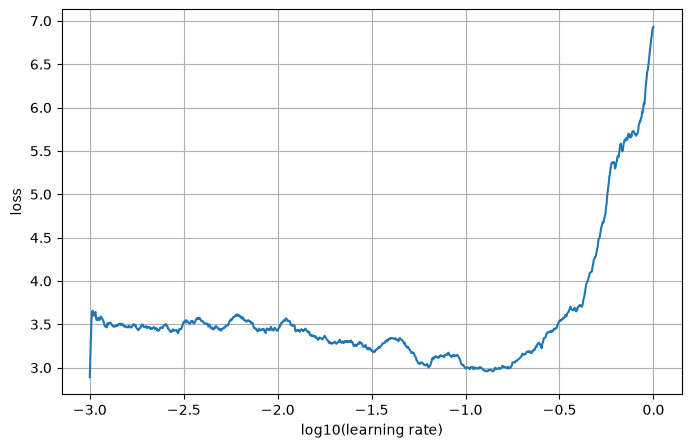

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(lri, loss_smooth)
plt.xlabel("log10(learning rate)")
plt.ylabel("loss")
plt.grid()
plt.show()

In [82]:
# implementation with batch learning and better learning rate

for i in range(10000):

    #a minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))
    
    #forward pass 
    emb = C[Xtr[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        lr = 0.2
        p.data += -lr* p.grad

print(loss.item())

2.5995333194732666


In [83]:
# loss on the dev set 

emb = C[Xdev] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.4363691806793213


In [85]:
# loss on the test set

emb = C[Xte] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
print(loss.item())

2.441288948059082


As the loss on the test set is less than on the training set, the model underfits

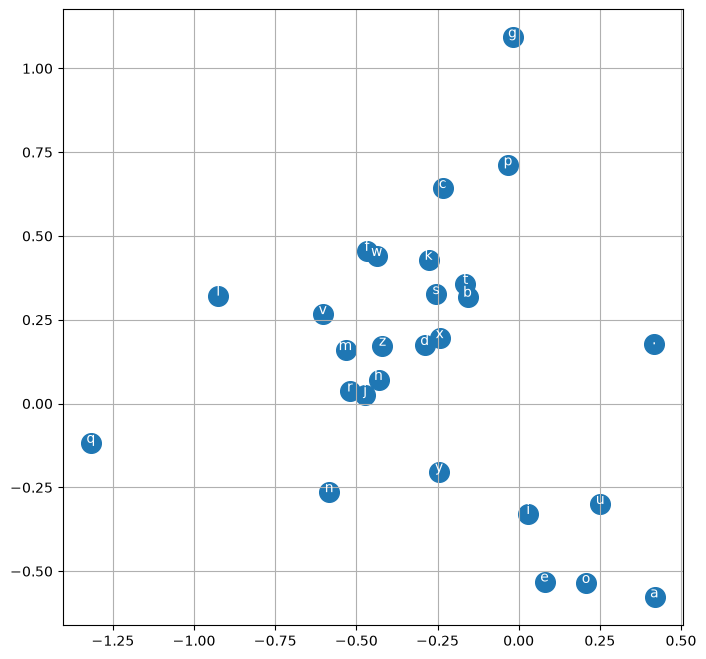

In [86]:
# plot of embeddings in 2d showing their similarity

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center',color='white')
plt.grid('minor')

In [87]:
#sampling

g = torch.Generator().manual_seed(2147483647+3)

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]      # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(
            probs,
            num_samples=1
        ).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

ben.
zenninneen.
jio.
soyrali.
aken.
kandosr.
ema.
heyliesen.
kyr.
jovloir.
beel.
kabeinree.
jari.
brayrynvananietelseer.
ana.
zens.
kzi.
jayer.
zabrie.
hadri.


In [90]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10),generator=g)
W1 = torch.randn((30,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C, W1, b1, W2, b2]

In [91]:
# number of parameters in total

sum(p.nelement() for p in parameters)

6097

In [93]:
for p in parameters:
    p.requires_grad = True

In [99]:
# now training with 10 dimensional embedding for each word

for i in range(10000):

    #a minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))
    
    #forward pass 
    emb = C[Xtr[ix]] #(32,3,10)
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    for p in parameters:
        lr = 0.05
        p.data += -lr* p.grad

print(loss.item())

1.808359980583191


In [100]:
# loss on the test set

emb = C[Xte] #(32,3,2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
print(loss.item())

2.2464165687561035


In [101]:
#sampling

g = torch.Generator().manual_seed(2147483647+3)

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]      # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(
            probs,
            num_samples=1
        ).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

chriselen.
atha.
jamylieen.
mariu.
tand.
mollanira.
yaile.
seviirettolen.
kaiiah.
gweemegli.
nuy.
tareeleni.
ymanaldi.
evoste.
dalya.
verleeann.
jira.
nigla.
marielee.
nariyree.
